In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from FractionalLorenz import FractionalLorenz


def crossing_points(p1, curve1, p2, curve2, n_grid=2000):
    """
    Crossing points of two Lorenz curves defined on different grids.
    """
    # Common grid
    p = np.linspace(0, 1, n_grid)
    c1 = np.interp(p, p1, curve1)
    c2 = np.interp(p, p2, curve2)
    diff = c1 - c2
    idx = np.where(np.diff(np.sign(diff)) != 0)[0]
    crossings = []
    for k in idx:
        x1, x2 = p[k], p[k+1]
        y1, y2 = diff[k], diff[k+1]
        pcross = x1 - y1 * (x2-x1)/(y2-y1)
        # Ignore the trivial endpoints
        if 1e-8 < pcross < 1-1e-8:
            crossings.append(pcross)
    return crossings


def minimal_fractional_order(
    y1,
    y2,
    weight1=None,
    weight2=None,
    kind="relative",
    max_order=9,
    step=0.1,
):
    """
    Compute the minimal (possibly fractional) Lorenz order between curves of y1 and y2.
    y1, y2 : array-like
    """
    for s in range(1, max_order + 1):
        L1 = FractionalLorenz()
        L2 = FractionalLorenz()
        # Integer order
        L1.fit(
            y1,
            weight=weight1,
            dominance_param=s,
            kind=kind,
        )
        L2.fit(
            y2,
            weight=weight2,
            dominance_param=s,
            kind=kind,
        )
        p1 = np.concatenate(([0.0], L1.t1.squeeze()))
        c1 = np.concatenate(([0.0], L1.C))
        p2 = np.concatenate(([0.0], L2.t1.squeeze()))
        c2 = np.concatenate(([0.0], L2.C))
        cross = crossing_points(p1, c1, p2, c2)
        cross = [x for x in cross if 0.01 <= x <= 0.99]
        if len(cross) == 0:
            return float(s)
        # Fractional orders
        for c in np.arange(step, 1.0, step):
            L1.fit(
                y1,
                weight=weight1,
                dominance_param=s,
                fractional_param=c,
                kind=kind,
            )
            L2.fit(
                y2,
                weight=weight2,
                dominance_param=s,
                fractional_param=c,
                kind=kind,
            )
            c1 = np.concatenate(([0.0], L1.CC))
            c2 = np.concatenate(([0.0], L2.CC))
            cross = crossing_points(p1, c1, p2, c2)
            cross = [x for x in cross if 0.01 <= x <= 0.99]
            print(f"{s+c:.1f}: {cross}")
            if len(cross) == 0:
                return s + c

    return None

## Data

In [ ]:
import numpy as np

# Income distributions
y1 = np.array([2, 4, 5, 9, 10, 12, 15, 18, 22, 30])
y2 = np.array([2, 3, 5, 8, 11, 13, 16, 20, 24, 35])

# Sampling weights (not mandatory)
weight1 = np.array([1, 2, 1, 1, 3, 1, 2, 1, 1, 2], dtype=float)
weight2 = np.array([2, 1, 1, 2, 1, 2, 1, 1, 2, 1], dtype=float)

## Relative 

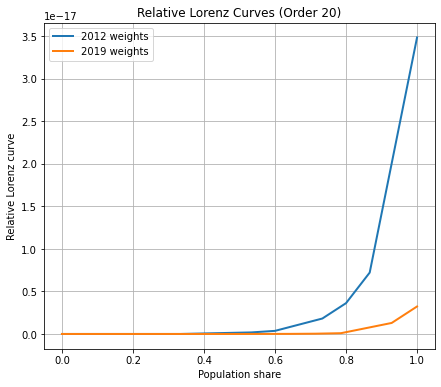

crossing_points [0.06653326663331666, 0.3052013078733583, 0.3331972510832752]
Inequality index 0.8387929599245203 0.887525130820656
1.1: [0.07968378388273345, 0.30616649863709616, 0.33788180254371863, 0.5170444142233686, 0.6057182217314345, 0.731443875516451, 0.7376799675969915, 0.7905601536616653, 0.883915851865209]
1.2: [0.09701687256787396, 0.8080345922276356, 0.8799205781590733]
1.3: [0.2156362780412971, 0.8577115917417164, 0.8687783984192913]
1.4: [0.27801471368006153, 0.30649818790601707, 0.33742806939656045]
1.5: [0.35167248456079603]
1.6: [0.37817242170004134]
1.7: [0.42710204750776104, 0.5116634037602276, 0.6036244330298034]
1.8: [0.9039231022157233]
1.9: []
1.9


In [ ]:
# Order
order = 1
fractional_param = None
kind = "relative"

# Relative Lorenz curve (2012 weights)
L12 = FractionalLorenz()
L12.fit(y1,weight=weight1,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Relative Lorenz curve (2019 weights)
L19 = FractionalLorenz()
L19.fit(y2,weight=weight2,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Plot
p12 = np.concatenate(([0.0], L12.t1.squeeze()))
p19 = np.concatenate(([0.0], L19.t1.squeeze()))
if fractional_param is None:
    c12 = np.concatenate(([0.0], L12.C))
    c19 = np.concatenate(([0.0], L19.C))
else:
    c12 = np.concatenate(([0.0], L12.CC))
    c19 = np.concatenate(([0.0], L19.CC))

plt.figure(figsize=(7, 6))
plt.plot(p12, c12, lw=2, label="2012 weights")
plt.plot(p19, c19, lw=2, label="2019 weights")
#plt.plot([0, 1], [0, 1], "k--", label="Equality line")
plt.xlabel("Population share")
plt.ylabel("Relative Lorenz curve")
plt.title(f"Relative Lorenz Curves (Order {order})")
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print("crossing_points", crossing_points(p12, c12, p19, c19))
print("Inequality index", L12.inequality_index(), L19.inequality_index())
print(minimal_fractional_order(y1,y2,weight1,weight2,kind=kind))

## Absolute

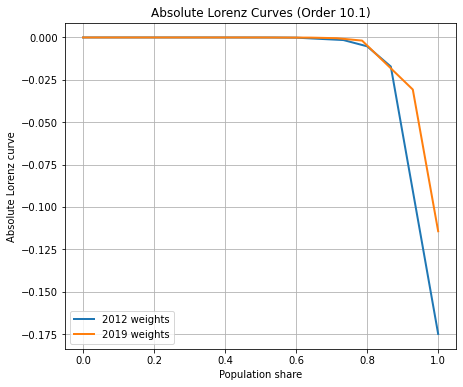

crossing_points [0.06653326663331666, 0.2974513502769733, 0.3339149998455548, 0.8213361481373511, 0.8677368662993207]
Inequality index 10.112439596058543 10.93304813540335
1.1: [0.09663430112390199, 0.16503519167701317, 0.36137362250568644, 0.5009225805655635, 0.6353760467162685, 0.662513621644955]
1.2: []
1.2


In [20]:
# Order
order = 10
kind = "absolute"
fractional_param = 0.1

# Absolute Lorenz curve (2012 weights)
L12 = FractionalLorenz()
L12.fit(y1,weight=weight1,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Absolute Lorenz curve (2019 weights)
L19 = FractionalLorenz()
L19.fit(y2,weight=weight2,dominance_param=order,fractional_param=fractional_param,kind=kind)

# Plot
p12 = np.concatenate(([0.0], L12.t1.squeeze()))
p19 = np.concatenate(([0.0], L19.t1.squeeze()))
if fractional_param is None:
    c12 = np.concatenate(([0.0], L12.C))
    c19 = np.concatenate(([0.0], L19.C))
else:
    c12 = np.concatenate(([0.0], L12.CC))
    c19 = np.concatenate(([0.0], L19.CC))
plt.figure(figsize=(7, 6))
plt.plot(p12, c12, lw=2, label="2012 weights")
plt.plot(p19, c19, lw=2, label="2019 weights")
#plt.plot([0, 1], [0, 1], "k--", label="Equality line")

plt.xlabel("Population share")
plt.ylabel("Absolute Lorenz curve")
plt.title(f"Absolute Lorenz Curves (Order {order}.1)")
#plt.xlim(0, 1)
#plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print("crossing_points", crossing_points(p12, c12, p19, c19))
print("Inequality index", L12.inequality_index(), L19.inequality_index())
print(minimal_fractional_order(y1,y2,weight1,weight2,kind=kind))